Es posible reescribir todo el código de una forma mas sencilla y compacta, haciendo uso de la libreria SciPy:

Preparamos las condiciones inciales y las características del sistema a simular.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

#Constantes del modelo SIR
beta = 0.9 #Tasa de infección
gamma = 0.1 #Tasa de recuperación
N = 7e9 #Población total
S0 = N - 1 #Número inicial de susceptibles
I0 = 1 #Número inicial de infectados
R0 = 0 #Número inicial de recuperados
dias = 365 #Tiempo de simulación


Escribimos el sistema de ED para el modelo SIR.

In [2]:
#Sistema de ED del modelo SIR
def SIR(t,y, S, I, R, beta, gamma, N):
    S, I, R = y
    
    dS = -(beta * S * I)/N
    dI = (beta * S * I)/N - gamma * I
    dR = gamma * I
    return dS, dI, dR

Separamos de forma uniforme el paso del tiempo y usamos la función solve_ivp para resolver el sistema de ED de SIR haciendo uso del metodo Rungen-Kutta 4 (RK45).

In [ ]:
#Resolución del sistema de ED utilizando solve_ivp
t_eval = np.linspace(0, dias, dias)

sol = solve_ivp(SIR, (0, dias), [S0, I0, R0], args=(S0, I0, R0, beta, gamma, N), t_eval=t_eval, method='RK45')

S, I, R = sol.y
t = sol.t


Asi obteniendo S, I y R como una evolución temporal continua bajo el sistema de ED del modelo SIR.

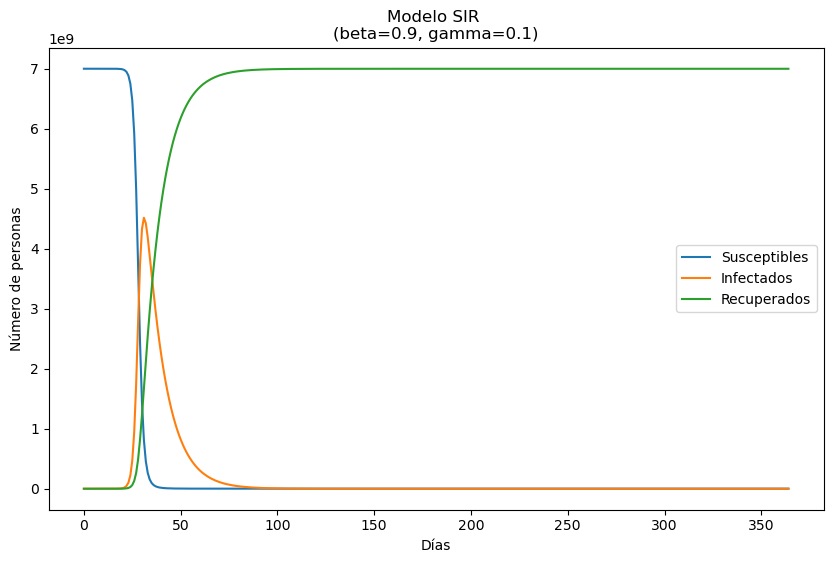

In [5]:
#Gráfica de resultados
plt.figure(figsize=(10,6))
plt.plot(S, label='Susceptibles')
plt.plot(I, label='Infectados')
plt.plot(R, label='Recuperados')
plt.xlabel('Días')
plt.ylabel('Número de personas')
plt.title('Modelo SIR \n(beta={}, gamma={})'.format(beta, gamma))
plt.legend()
plt.show()

Recuperando un resultado similar al obtenido de forma "manual".

Referencias:

-[Detalles en la funcionalidad de scipy.integrate](https://docs.scipy.org/doc/scipy/tutorial/integrate.html)

-[Metodo Runge-Kutta](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods)

-[Runge-Kutta 4,5 (RK45)](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta%E2%80%93Fehlberg_method)
